<a href="https://colab.research.google.com/github/santosoj160/Advanced-Exploratory-Data-Analysis-on-Ecommerce-Dataset-Using-Python/blob/main/EDA_Ecommerce_Assignment_Joko_Santoso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nama: Joko Santoso
Data Analyst and Business Intelligence Analyst 23

Github : [Ecommerce Analyst](https://github.com/santosoj160/Advanced-Exploratory-Data-Analysis-on-Ecommerce-Dataset-Using-Python)

Linkedin : [Joko Santoso](https://www.linkedin.com/in/joko-santoso-484769144/)

#Data Understanding

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
# Install library untuk download file dari Google Drive
!pip install -q gdown

In [11]:
# Download dataset ecommerce.csv dari Google Drive
import gdown

file_id = "1QCJfqvNRfG2KsAgCG0pqdixvozvrsD9R"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(
    url,
    "ecommerce.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1QCJfqvNRfG2KsAgCG0pqdixvozvrsD9R
To: /content/ecommerce.csv
100%|██████████| 459k/459k [00:00<00:00, 51.1MB/s]


'ecommerce.csv'

In [12]:
# Membaca dataset ecommerce.csv
df = pd.read_csv("ecommerce.csv")

In [13]:
# Menampilkan 5 baris pertama dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [14]:
df.shape

(4870, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [8]:
df.describe()


,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.000000,4870.000000,4870.000000,4870.000000
mean,560586.577413,12.945791,2.937057,15291.004312
std,13211.347819,38.145988,4.744515,1709.035002
min,536365.000000,1.000000,0.040000,12347.000000
25%,548861.000000,2.000000,1.250000,13975.000000
50%,561895.000000,5.000000,1.950000,15144.000000
75%,572126.000000,12.000000,3.750000,16793.250000
max,581585.000000,992.000000,145.000000,18283.000000


In [13]:
# Mengecek jumlah missing value pada setiap kolom
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [14]:
# Mengecek jumlah data duplikat
df.duplicated().sum()

np.int64(0)

In [15]:
# Menampilkan seluruh nama kolom
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [23]:
# Menampilkan tipe data setiap kolom
df.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object
Year,int32
Month,int32


#Feature Engineering

In [24]:
# Membuat kolom Revenue
# Revenue = Quantity × UnitPrice

df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Menampilkan hasil
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,1,2.08,2.08
1,2,2.55,5.10
2,1,1.65,1.65
3,12,1.25,15.00
4,3,0.85,2.55


In [25]:
# Mengubah InvoiceDate menjadi format datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Mengecek hasil konversi
df['InvoiceDate'].head()

,InvoiceDate
0,2011-05-25 17:31:00
1,2011-07-24 11:58:00
2,2011-07-19 12:54:00
3,2011-07-13 11:34:00
4,2011-02-20 12:23:00


In [26]:
# Mengambil tahun transaksi

df['Year'] = df['InvoiceDate'].dt.year

df[['InvoiceDate','Year']].head()

,InvoiceDate,Year
0,2011-05-25 17:31:00,2011
1,2011-07-24 11:58:00,2011
2,2011-07-19 12:54:00,2011
3,2011-07-13 11:34:00,2011
4,2011-02-20 12:23:00,2011


In [27]:
# Mengambil nomor bulan transaksi

df['Month'] = df['InvoiceDate'].dt.month

# Mengambil nama bulan transaksi
df['Month_Name'] = df['InvoiceDate'].dt.month_name()

df[['InvoiceDate','Month', 'Month_Name']].head()

,InvoiceDate,Month,Month_Name
0,2011-05-25 17:31:00,5,May
1,2011-07-24 11:58:00,7,July
2,2011-07-19 12:54:00,7,July
3,2011-07-13 11:34:00,7,July
4,2011-02-20 12:23:00,2,February


In [28]:
# Mengambil tanggal transaksi

df['Day'] = df['InvoiceDate'].dt.day

df[['InvoiceDate','Day']].head()

,InvoiceDate,Day
0,2011-05-25 17:31:00,25
1,2011-07-24 11:58:00,24
2,2011-07-19 12:54:00,19
3,2011-07-13 11:34:00,13
4,2011-02-20 12:23:00,20


In [29]:
# Menampilkan dataset setelah feature engineering

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Month_Name,Day,Revenue
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2011,5,May,25,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,2011,7,July,24,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,2011,7,July,19,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,2011,7,July,13,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2011,2,February,20,2.55


## Insight Feature Engineering

Beberapa fitur baru ditambahkan untuk mendukung proses analisis:

- Revenue digunakan untuk mengukur nilai transaksi.
- Year digunakan untuk analisis tahunan.
- Month dan Month_Name digunakan untuk analisis tren bulanan.
- Day digunakan untuk melihat pola transaksi harian.

Feature engineering dilakukan agar proses eksplorasi data menjadi lebih mudah dan menghasilkan insight yang lebih mendalam.

# Analysis Question 1 Top 10 Revenue by Country

## Which country generates the highest revenue?

Analisis dilakukan untuk mengetahui negara yang memberikan kontribusi revenue terbesar bagi perusahaan.

In [30]:
# Menghitung total revenue per negara

country_revenue = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,93011.36
Netherlands,3622.33
Germany,3363.77
EIRE,3156.78
France,2320.55
Sweden,988.74
Australia,937.00
Switzerland,902.52
Portugal,562.90


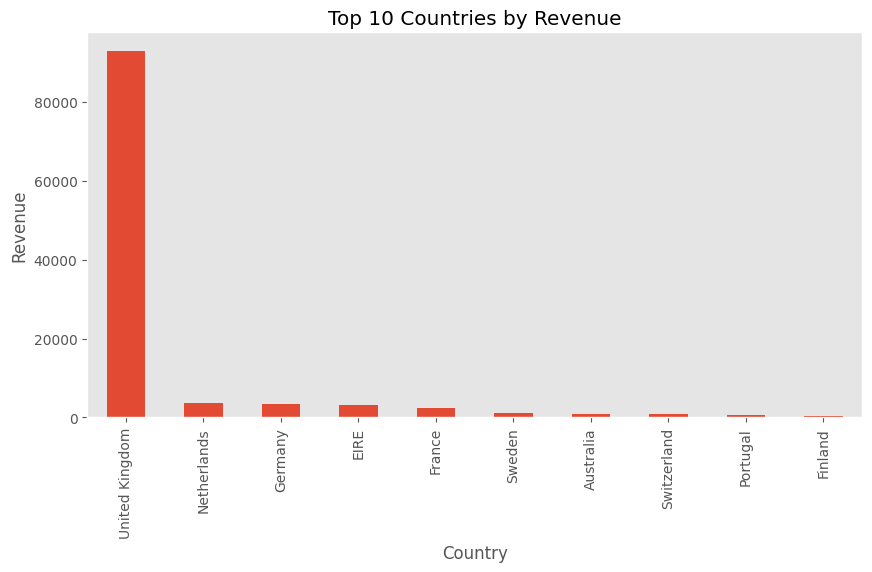

In [60]:
# Visualisasi Top 10 Revenue by Country

plt.figure(figsize=(10,5))

country_revenue.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.grid(False)

plt.show()

## Insight Question 1

Berdasarkan hasil analisis, United Kingdom memberikan kontribusi revenue yang jauh lebih besar dibandingkan negara lainnya. dengan revenue total 93011

Negara dengan revenue tertinggi dapat dianggap sebagai pasar utama perusahaan dan dapat menjadi fokus strategi pemasaran serta pengembangan bisnis.

# Analysis Question 2 Top Selling Products

## Which products have the highest sales quantity?

Analisis dilakukan untuk mengetahui produk yang paling banyak terjual berdasarkan jumlah unit yang dibeli pelanggan.

In [32]:
# Menghitung total quantity terjual per produk

top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1291
CREAM HEART CARD HOLDER,1032
"WRAP, BILLBOARD FONTS DESIGN",825
JUMBO BAG RED RETROSPOT,783
MIRROR MOSAIC T-LIGHT HOLDER,720
ASSORTED COLOURS SILK FAN,648
SWEETHEART BIRD HOUSE,621
JUMBO BAG ALPHABET,608
JUMBO BAG STRAWBERRY,585


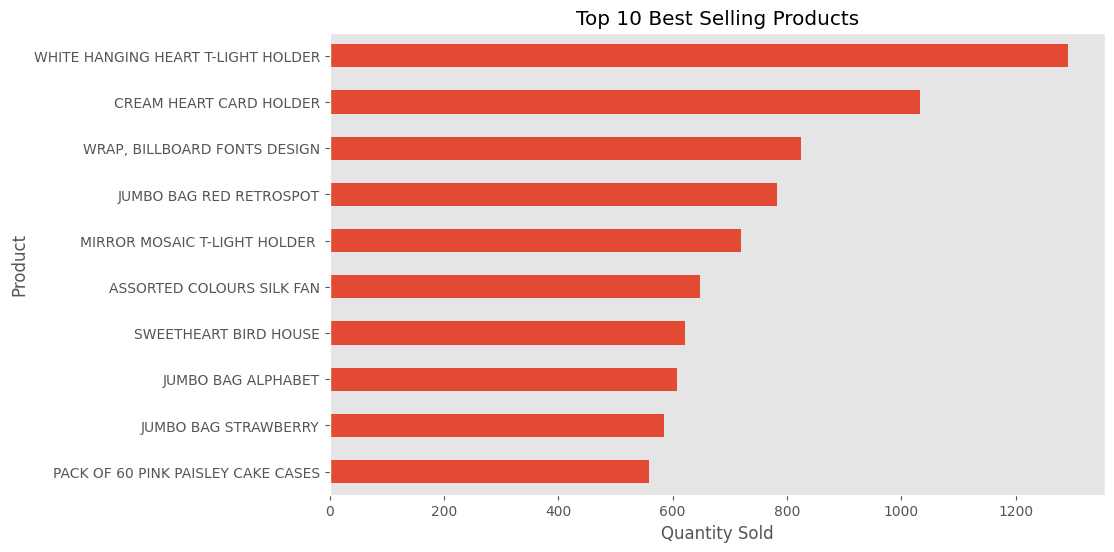

In [64]:
# Visualisasi 10 produk terlaris

plt.figure(figsize=(10,6))

top_products.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')


plt.grid(False)
plt.show()

## Insight Question 2

Berdasarkan hasil visualisasi, produk WHITE HANGING HEART T-LIGHT HOLDER	1291 memiliki jumlah penjualan yang jauh lebih tinggi dibandingkan produk lainnya.

Produk dengan performa terbaik dapat dijadikan fokus dalam strategi inventory management dan promosi penjualan.

# Analysis Question 3 Monthly Revenue Trend (Datetime Analysis)

## How does revenue change across months?

Analisis dilakukan untuk melihat tren revenue berdasarkan periode waktu.

In [34]:
# Menghitung revenue per bulan

monthly_revenue = (
    df.groupby(['Month','Month_Name'])['Revenue']
      .sum()
      .reset_index()
      .sort_values('Month')
)

monthly_revenue

,Month,Month_Name,Revenue
0,1,January,6247.52
1,2,February,6152.46
2,3,March,7162.64
3,4,April,6357.63
4,5,May,6987.24
5,6,June,7203.93
6,7,July,7569.27
7,8,August,9904.91
8,9,September,9761.11
9,10,October,10177.38


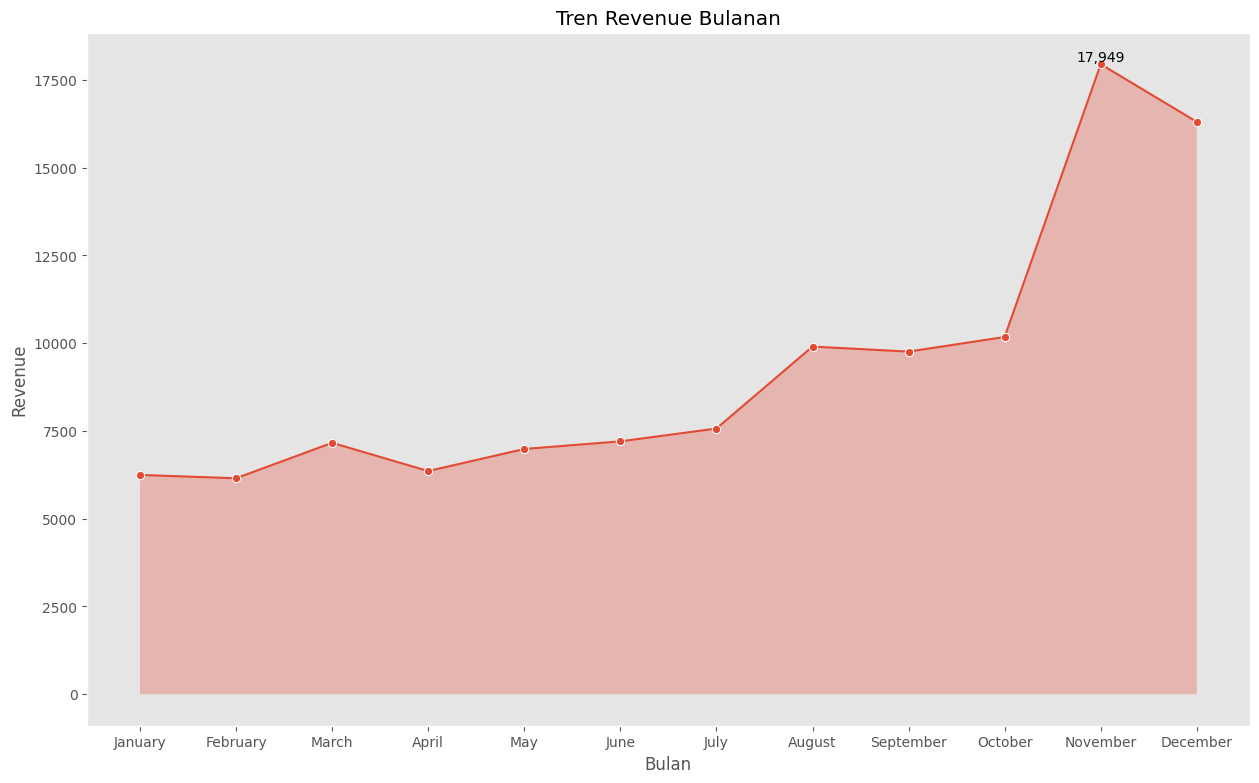

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memvisualisasikan tren revenue bulanan

plt.figure(figsize=(15,9))

sns.lineplot(
    data=monthly_revenue,
    x='Month_Name',
    y='Revenue',
    marker='o' # Menampilkan titik penanda pada setiap bulan
)

# Menambahkan warna pada area di bawah garis tren menggunakan plt.fill_between
plt.fill_between(
    monthly_revenue['Month_Name'],
    monthly_revenue['Revenue'],
    alpha=0.3 # Mengatur transparansi warna area
)

plt.title('Tren Revenue Bulanan') # Judul plot
plt.xlabel('Bulan') # Label sumbu X
plt.ylabel('Revenue') # Label sumbu Y

# Mencari bulan dengan revenue tertinggi
max_revenue_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]

# Menambahkan label data hanya untuk titik revenue tertinggi
x = max_revenue_month['Month_Name']
y = max_revenue_month['Revenue']
plt.text(x, y, f'{y:,.0f}', color='black', ha='center', va='bottom')

plt.grid(False)

plt.show() # Menampilkan plot

## Insight Question 3

Berdasarkan grafik tren revenue bulanan, terlihat bahwa revenue cenderung mengalami peningkatan dari awal hingga akhir tahun.

Pada periode Januari hingga Juli, kenaikan revenue terjadi secara bertahap dengan fluktuasi yang relatif kecil. Memasuki bulan Agustus hingga Oktober, revenue meningkat lebih signifikan dibandingkan bulan-bulan sebelumnya.

Revenue tertinggi terjadi pada bulan November dengan nilai sekitar 17.949, kemudian sedikit menurun pada bulan Desember namun masih berada pada level yang tinggi dibandingkan bulan lainnya.

Temuan ini menunjukkan adanya peningkatan aktivitas pembelian menjelang akhir tahun, sehingga periode November dan Desember dapat dianggap sebagai periode dengan performa penjualan terbaik.

# Analysis Question 4 Revenue by Country and Month (Pivot Table)

## How does revenue vary across countries and months?

Analisis dilakukan menggunakan Pivot Table untuk melihat distribusi revenue berdasarkan negara dan bulan.

In [45]:
# Top 10 negara berdasarkan revenue
top_countries = (
    df.groupby('Country')['Revenue']
      .sum()
      .nlargest(10)
      .index
)

pivot_revenue_top = pd.pivot_table(
    df[df['Country'].isin(top_countries)],
    values='Revenue',
    index='Country',
    columns='Month_Name',
    aggfunc='sum',
    fill_value=0
)

pivot_revenue_top

Month_Name,April,August,December,February,January,July,June,March,May,November,October,September
Country,,,,,,,,,,,,
Australia,0.00,91.80,0.00,0.00,27.00,44.40,126.72,564.00,66.48,0.00,0.00,16.60
EIRE,60.60,115.72,255.50,251.17,87.60,968.30,92.90,94.29,136.50,701.44,281.90,110.86
Finland,0.00,0.00,0.00,0.00,244.08,24.90,0.00,122.04,0.00,0.00,41.55,0.00
France,30.60,60.90,184.82,102.42,202.21,343.60,549.90,160.26,68.10,220.35,131.74,265.65
Germany,356.75,237.89,254.32,213.15,209.50,171.22,290.92,431.82,171.45,320.02,481.75,224.98
Netherlands,90.00,697.00,0.00,360.00,208.32,0.00,855.75,105.00,365.60,82.50,278.16,580.00
Portugal,35.40,0.00,334.50,0.00,85.80,16.50,0.00,0.00,4.95,0.00,73.25,12.50
Sweden,15.30,40.00,208.80,0.00,75.60,17.34,20.40,264.00,0.00,30.30,300.00,17.00
Switzerland,39.60,177.38,0.00,108.62,20.10,82.00,0.00,156.60,20.80,159.48,137.94,0.00


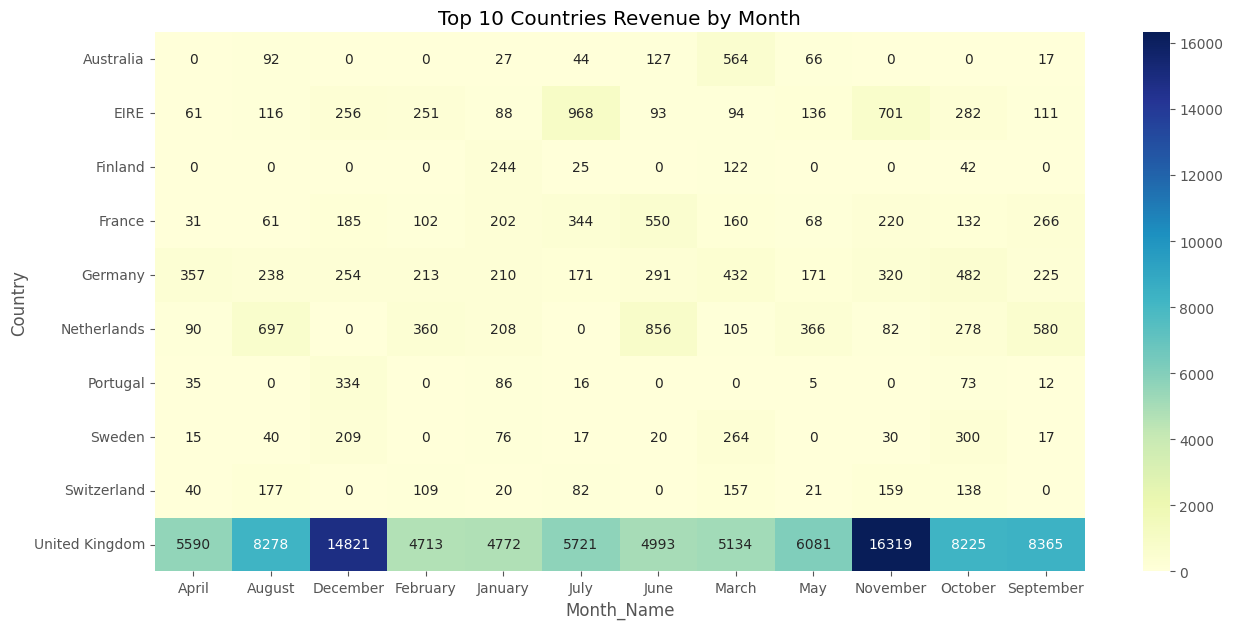

In [58]:
plt.figure(figsize=(15,7))

sns.heatmap(
    pivot_revenue_top,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Top 10 Countries Revenue by Month')

plt.show()

## Insight Question 4

Hasil visualisasi menunjukkan bahwa United Kingdom mendominasi revenue perusahaan pada hampir seluruh bulan pengamatan.

Konsentrasi revenue yang tinggi pada satu negara menunjukkan bahwa perusahaan masih sangat bergantung pada pasar United Kingdom.

Kondisi ini dapat menjadi peluang sekaligus risiko. Peluang karena perusahaan memiliki pasar yang kuat, namun risiko apabila terjadi penurunan permintaan pada negara tersebut maka revenue perusahaan dapat terdampak secara signifikan.

Oleh karena itu, perusahaan dapat mempertimbangkan strategi ekspansi pada negara lain untuk meningkatkan diversifikasi sumber revenue.

#Analysis Question 5 - Customer Purchasing Behavior (Crosstab)

## Which countries have the highest number of transactions?

Analisis dilakukan untuk mengetahui negara yang paling aktif melakukan transaksi pada platform e-commerce.

In [50]:
# Membuat kategori harga

df['Price_Category'] = pd.cut(
    df['UnitPrice'],
    bins=[0,5,20,100,1000],
    labels=['Murah','Sedang','Mahal','Premium']
)

In [51]:
# Crosstab negara dan kategori harga

country_price = pd.crosstab(
    df['Country'],
    df['Price_Category']
)

country_price.head()

Price_Category,Murah,Sedang,Mahal,Premium
Country,,,,
Australia,12,1,0,0
Austria,5,2,0,0
Belgium,20,1,0,0
Brazil,1,0,0,0
Canada,2,0,0,0


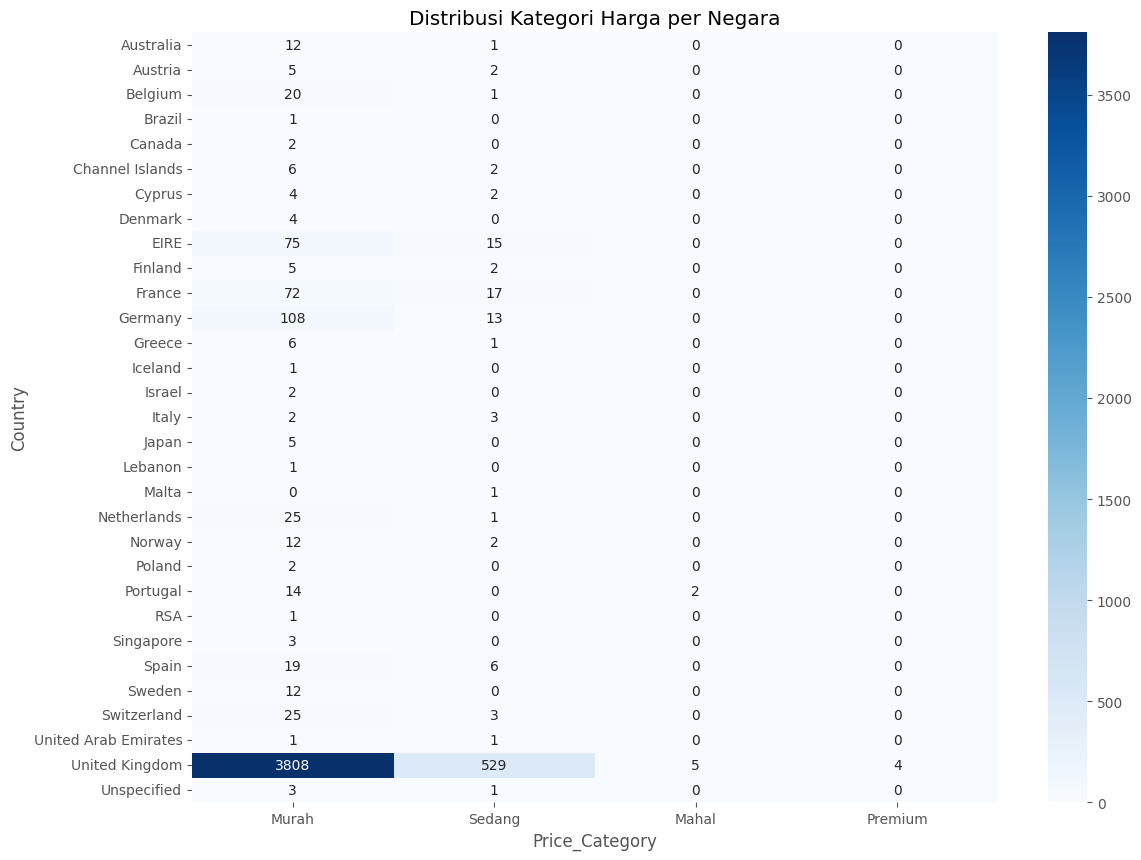

In [53]:
plt.figure(figsize=(13,10))

sns.heatmap(
    country_price,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Distribusi Kategori Harga per Negara')

plt.show()

## Insight Question 5

Berdasarkan heatmap distribusi kategori harga per negara, transaksi didominasi oleh kategori Murah pada hampir seluruh negara.

United Kingdom memiliki jumlah transaksi paling besar dibandingkan negara lain, terutama pada kategori Murah dan Sedang. Hal ini menunjukkan bahwa sebagian besar penjualan perusahaan berasal dari produk dengan harga relatif rendah di pasar United Kingdom.

Produk kategori Mahal dan Premium jumlahnya sangat sedikit dan hanya muncul di beberapa negara tertentu. Dengan demikian, perusahaan saat ini lebih bergantung pada volume penjualan produk murah dibandingkan penjualan produk premium.

Correlation Heatmap

# Multivariate Analysis

## Correlation Heatmap

Analisis korelasi dilakukan untuk mengetahui hubungan antar variabel numerik dalam dataset.

In [41]:
# Memilih kolom numerik

numeric_df = df[
    [
        'Quantity',
        'UnitPrice',
        'Revenue'
    ]
]

numeric_df.head()

,Quantity,UnitPrice,Revenue
0,1,2.08,2.08
1,2,2.55,5.10
2,1,1.65,1.65
3,12,1.25,15.00
4,3,0.85,2.55


In [42]:
# Menghitung korelasi

corr_matrix = numeric_df.corr()

corr_matrix

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.083283,0.788586
UnitPrice,-0.083283,1.000000,0.091612
Revenue,0.788586,0.091612,1.000000


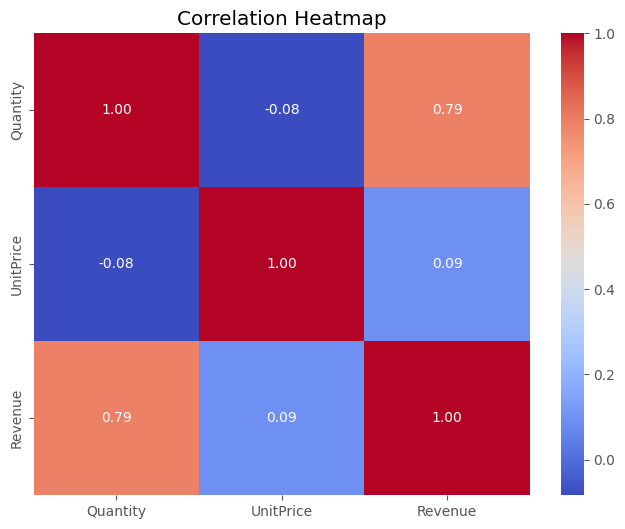

In [43]:
# Visualisasi korelasi

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Correlation Heatmap Insight

Berdasarkan hasil correlation heatmap, variabel Quantity memiliki korelasi positif yang cukup kuat terhadap Revenue dengan nilai korelasi sebesar 0,79. Hal ini menunjukkan bahwa semakin banyak produk yang terjual, maka revenue cenderung meningkat.

Sementara itu, UnitPrice memiliki korelasi yang sangat lemah terhadap Revenue dengan nilai korelasi sebesar 0,09. Hasil ini menunjukkan bahwa pada dataset ini peningkatan revenue lebih dipengaruhi oleh jumlah produk yang terjual dibandingkan harga produk itu sendiri.

Selain itu, korelasi antara Quantity dan UnitPrice bernilai -0,08 yang menunjukkan bahwa tidak terdapat hubungan yang signifikan antara jumlah pembelian dan harga produk.

Secara keseluruhan, faktor utama yang mendorong peningkatan revenue pada dataset ini adalah volume penjualan (Quantity), bukan kenaikan harga produk.